In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("heart_disease_risk_dataset_earlymed.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (70000, 19)


In [3]:
# ================================
# 3. DATA PREPROCESSING
# ================================

# Drop missing values (if any)
df = df.dropna()

# Target column
target_column = "Heart_Risk"

X = df.drop(columns=[target_column])
y = df[target_column]

# Save columns for later manual input
training_columns = X.columns.tolist()

In [4]:
# ================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# ================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)


In [5]:
# ================================
# 5. FEATURE SCALING
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [6]:
# ================================
# 6. TRAIN MODEL
# ================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [7]:
# ================================
# 7. EVALUATION
# ================================
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))
test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== RESULTS =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))


===== RESULTS =====
Training Accuracy   : 0.9922
Validation Accuracy : 0.9913
Test Accuracy       : 0.9911
Precision           : 0.9914
Recall              : 0.9909
F1 Score            : 0.9911

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



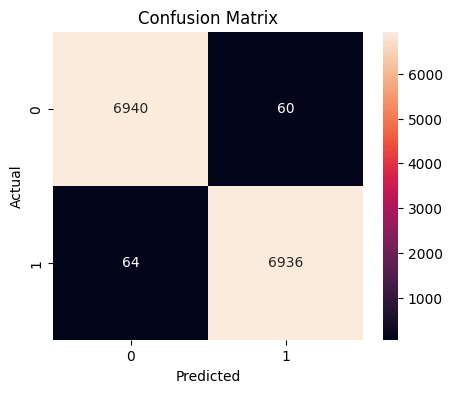

In [8]:
# ================================
# 8. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# ================================
# 9. SAVE MODEL
# ================================
joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(training_columns, "columns.pkl")

print("\nModel saved successfully.")


Model saved successfully.


In [10]:
# ================================
# 10. MANUAL INPUT TEST
# ================================
manual_input = {
    'Chest_Pain': 1,
    'Shortness_of_Breath': 1,
    'Fatigue': 0,
    'Palpitations': 0,
    'Dizziness': 0,
    'Swelling': 0,
    'Pain_Arms_Jaw_Back': 1,
    'Cold_Sweats_Nausea': 0,
    'High_BP': 1,
    'High_Cholesterol': 1,
    'Diabetes': 0,
    'Smoking': 1,
    'Obesity': 0,
    'Sedentary_Lifestyle': 1,
    'Family_History': 1,
    'Chronic_Stress': 1,
    'Gender': 1,
    'Age': 55
}

input_df = pd.DataFrame([manual_input])

# Ensure column order
input_df = input_df[training_columns]

# Scale
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled)[0]
probability = model.predict_proba(input_scaled)[0][1]

print("\n===== MANUAL TEST =====")
print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Probability: {probability:.4f}")


===== MANUAL TEST =====
Prediction: Heart Disease
Probability: 0.8157
